In [4]:
import torch
import os
from torchvision import transforms
from torch.utils.data import DataLoader,Dataset
import numpy as np
from PIL import Image

In [5]:
class ImageProcessor():
    def __init__(self,root_dir,transformation=None):
        self.root_dir = root_dir
        self.transformation = transformation


        self.all_img_path = [
            os.path.join(root_dir,img)
            for img in os.listdir(root_dir)
        ]
    def __len__(self):
            return len(self.all_img_path)

    def __getitem__(self,idx):
        img_path = self.all_img_path[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transformation:
            img = self.transformation(img)
        return img

In [6]:
root_dir = "./img_align_celeba"
transformation = transforms.Compose(
    [
        transforms.CenterCrop(178),
        transforms.Resize(64),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ]
)


In [7]:
dataset = ImageProcessor(root_dir,transformation)
dataloader = DataLoader(
    dataset,
    batch_size = 178,
    shuffle = True
)

# Generator Network

In [8]:
import torch.nn as nn
import torch.optim as optim

class Generator(nn.Module):
    def __init__(self,img_channel=3,z_dim=100,feature_map=64):
        super(Generator,self).__init__()

        self.model = nn.Sequential(
            nn.ConvTranspose2d(z_dim,feature_map*8,kernel_size=4,stride=1,padding=0,bias=False),
            nn.BatchNorm2d(feature_map * 8),
            nn.ReLU(),

            nn.ConvTranspose2d(feature_map*8,feature_map*4,4,2,1,bias=False),
            nn.BatchNorm2d(feature_map * 4),
            nn.ReLU(),

            nn.ConvTranspose2d(feature_map*4,feature_map*2,4,2,1,bias=False),
            nn.BatchNorm2d(feature_map*2),
            nn.ReLU(),

            
            nn.ConvTranspose2d(feature_map*2,feature_map,4,2,1,bias=False),
            nn.BatchNorm2d(feature_map),
            nn.ReLU(),

            nn.ConvTranspose2d(feature_map,img_channel,4,2,1),
            nn.Tanh()
        )

    def forward(self,z):
        img = self.model(z)
        img = img.view(img.size(0),3,64,64)
        return img

# Discriminator Network

In [33]:
class Discriminator(nn.Module):
    def __init__(self,img_channel=3):
        super(Discriminator,self).__init__()

        self.model = nn.Sequential(
            nn.Conv2d(img_channel,64,4,2,1,bias=False), #feature_map = 64
            nn.LeakyReLU(0.2,inplace = True),

            nn.Conv2d(64,64*2,4,2,1,bias=False),
            nn.BatchNorm2d(64*2),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Conv2d(64*2,64*4,4,2,1,bias=False),
            nn.BatchNorm2d(64*4),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Conv2d(64*4,64*8,4,2,1,bias=False),
            nn.BatchNorm2d(64*8),
            nn.LeakyReLU(0.2,inplace=True),

            nn.Conv2d(64*8,1,4,1,0,bias=False),
            nn.Sigmoid()
        )

    def forward(self,img):
        img = self.model(img)
        return img.view(-1,1)

In [34]:
GAN_loss = nn.BCELoss()

generator = Generator()
g_optimizer = optim.Adam(generator.parameters(),lr=0.0002,betas=(0.5,0.999))

discriminator = Discriminator()
d_optimizer = optim.Adam(discriminator.parameters(),lr=0.0002,betas=(0.5,0.999))

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [36]:
generator = generator.to(device)
discriminator = discriminator.to(device)

## Train the model

In [37]:
def train(generator,discriminator,dataloader,epochs=10):
    for epoch in range(epochs):
        for i,imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size=real_imgs.size(0)

            #create real and fake img labels
            real_labels = torch.ones(batch_size,1).to(device)
            fake_labels = torch.zeros(batch_size,1).to(device)

            #Train the Discriminator
            d_optimizer.zero_grad()

            fake_imgs = generator(torch.randn(batch_size,100,1,1).to(device))

            real_loss = GAN_loss(discriminator(real_imgs),real_labels)
            fake_loss = GAN_loss(discriminator(fake_imgs.detach()),fake_labels)

            d_loss = (real_loss + fake_loss)/2

            d_loss.backward()
            d_optimizer.step()


            g_optimizer.zero_grad()
            g_loss = GAN_loss(discriminator(fake_imgs),real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i%50==0:
                print(f"for epoch:{epoch+1}/{epochs}... batch:{i+1}... G-loss:{g_loss}... D_loss:{d_loss}")

        save_generated_image(generator,epoch,device) #for each epochs

## save all  generated image

In [38]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_image(generator,epoch,device,num_imgs=8):
    z = torch.randn(num_imgs,100,1,1).to(device)
    generated_imgs = generator(z).detach().cpu()

    grid= torchvision.utils.make_grid(generated_imgs,nrow=4,normalize=True)

    #plotting
    plt.imshow(np.transpose(grid,(1,2,0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

for epoch:1/10... batch:1... G-loss:2.4349496364593506... D_loss:0.7423125505447388
for epoch:1/10... batch:51... G-loss:15.353190422058105... D_loss:0.12929442524909973
for epoch:1/10... batch:101... G-loss:4.6871562004089355... D_loss:0.167003333568573
for epoch:1/10... batch:151... G-loss:3.0614585876464844... D_loss:0.6503729820251465
for epoch:1/10... batch:201... G-loss:2.382819890975952... D_loss:0.33256345987319946
for epoch:1/10... batch:251... G-loss:3.3915553092956543... D_loss:0.38449159264564514
for epoch:1/10... batch:301... G-loss:2.8460946083068848... D_loss:0.3663080334663391
for epoch:1/10... batch:351... G-loss:2.1548593044281006... D_loss:0.3742196559906006
for epoch:1/10... batch:401... G-loss:1.0765495300292969... D_loss:0.4906092882156372
for epoch:1/10... batch:451... G-loss:3.927330493927002... D_loss:0.2898581326007843
for epoch:1/10... batch:501... G-loss:3.926555871963501... D_loss:0.46176475286483765
for epoch:1/10... batch:551... G-loss:2.494616985321045..

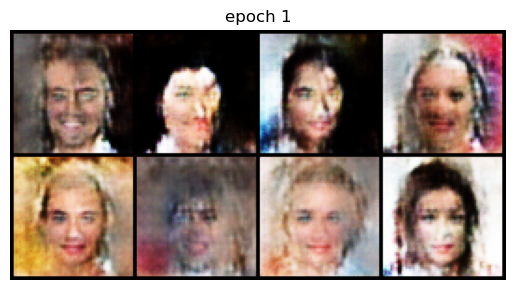

for epoch:2/10... batch:1... G-loss:5.853949069976807... D_loss:0.47919899225234985


In [ ]:
train(generator,discriminator,dataloader,epochs=10)